In [1]:
# ==================== 单元格 1：环境准备（Hard 版本） ====================
!pip install -q pandas numpy matplotlib seaborn scikit-learn transformers datasets accelerate torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import os
from tqdm.auto import tqdm


# 设置中文字体
!wget -O /usr/share/fonts/truetype/liberation/simhei.ttf "https://www.wfonts.com/download/data/2014/06/01/simhei/chinese.simhei.ttf" 2>/dev/null
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [2]:
# ==================== 单元格 2：Hard 难度数据加载与预处理 ====================
# ==================== Kaggle 单元格：数据加载 ====================
# -------------------- 1. 设置 Kaggle 数据路径 --------------------
data_dir = '/kaggle/input/datasets/victoriagyf/6980-scam-dataset/'

# 验证文件是否存在
for file in ['Hard_train.txt', 'Hard_dev.txt', 'Hard_test.txt']:
    full_path = os.path.join(data_dir, file)
    if not os.path.exists(full_path):
        print(f"警告：文件 {full_path} 不存在，请检查路径！")
    else:
        print(f"✅ 找到文件：{file}")

# -------------------- 2. 加载 Hard 数据 --------------------
def load_scamgen_txt(filepath):
    return pd.read_csv(filepath, sep='\t', header=None, names=['text', 'label'])

hard_train_df = load_scamgen_txt(data_dir + 'Hard_train.txt')
hard_val_df   = load_scamgen_txt(data_dir + 'Hard_dev.txt')
hard_test_df  = load_scamgen_txt(data_dir + 'Hard_test.txt')

print("Hard 训练集原始标签分布：\n", hard_train_df['label'].value_counts())

# -------------------- 2. 标签映射：0~3 → 1 (欺诈)，4 → 0 (正常) --------------------
def map_to_binary(label):
    return 0 if label == 4 else 1

for df in [hard_train_df, hard_val_df, hard_test_df]:
    df['label_id'] = df['label'].apply(map_to_binary)

print("\nHard 二分类训练集分布（0=正常，1=欺诈）：\n", hard_train_df['label_id'].value_counts())
print("Hard 二分类验证集分布：\n", hard_val_df['label_id'].value_counts())
print("Hard 二分类测试集分布：\n", hard_test_df['label_id'].value_counts())

# -------------------- 3. 特征提取（URL, Email, Phone）--------------------
email_pattern = re.compile(
    r"([a-z0-9!#$%&'*+/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+/=?^_`{|}~-]+)*(@|\sat\s)"
    r"(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(\.|\sdot\s))+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)",
    re.IGNORECASE
)
url_pattern = re.compile(
    r"http[s]?://(?:[a-zA-Z0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
)
phone_pattern = re.compile(r"\b\d{10,}\b")

def url_check(text): return 1 if url_pattern.search(str(text)) else 0
def email_check(text): return 1 if email_pattern.search(str(text)) else 0
def phone_check(text): return 1 if phone_pattern.search(str(text)) else 0

for df in [hard_train_df, hard_val_df, hard_test_df]:
    df['has_url']   = df['text'].apply(url_check)
    df['has_email'] = df['text'].apply(email_check)
    df['has_phone'] = df['text'].apply(phone_check)

print("特征提取完成。")

# -------------------- 4. 准备模型输入数据（list & numpy array）--------------------
hard_train_texts = hard_train_df['text'].tolist()
hard_train_labels = hard_train_df['label_id'].tolist()
hard_train_feats = hard_train_df[['has_url', 'has_email', 'has_phone']].values.astype(np.float32)

hard_val_texts = hard_val_df['text'].tolist()
hard_val_labels = hard_val_df['label_id'].tolist()
hard_val_feats = hard_val_df[['has_url', 'has_email', 'has_phone']].values.astype(np.float32)

hard_test_texts = hard_test_df['text'].tolist()
hard_test_labels = hard_test_df['label_id'].tolist()
hard_test_feats = hard_test_df[['has_url', 'has_email', 'has_phone']].values.astype(np.float32)

print(f"\nHard 训练集: {len(hard_train_texts)} | 验证集: {len(hard_val_texts)} | 测试集: {len(hard_test_texts)}")

# -------------------- 5. 计算类别权重（解决不平衡）--------------------
hard_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=hard_train_labels
)
hard_class_weights = torch.tensor(hard_class_weights, dtype=torch.float)
print("Hard 类别权重:", hard_class_weights)

# -------------------- 6. 示例查看 --------------------
print("\nHard 示例文本（前150字符）：")
print(hard_train_texts[0][:150])
print("标签：", hard_train_labels[0])

✅ 找到文件：Hard_train.txt
✅ 找到文件：Hard_dev.txt
✅ 找到文件：Hard_test.txt
Hard 训练集原始标签分布：
 label
0    20059
1    17278
3    15787
2    15250
4    13894
Name: count, dtype: int64

Hard 二分类训练集分布（0=正常，1=欺诈）：
 label_id
1    68374
0    13894
Name: count, dtype: int64
Hard 二分类验证集分布：
 label_id
1    5743
0    1294
Name: count, dtype: int64
Hard 二分类测试集分布：
 label_id
1    6153
0    1347
Name: count, dtype: int64
特征提取完成。

Hard 训练集: 82268 | 验证集: 7037 | 测试集: 7500
Hard 类别权重: tensor([2.9606, 0.6016])

Hard 示例文本（前150字符）：
小刘在吗？我是您同窗小陈 我找您有点事，太需要你的帮忙了 你能尽早给我转点吗 
标签： 1


In [3]:
# ==================== 单元格 3：Hard 版本的 Dataset & DataLoader ====================
MODEL_NAME = 'bert-base-uncased'   # 可改为 'bert-base-chinese' 提升中文效果
MAX_LEN = 128                      # 基于 Easy 的长度统计，Hard 应类似
BATCH_SIZE = 32                    # 根据 T4 16GB 显存设置
EPOCHS = 1                         # Hard 难度下 2 个 epoch 足够
LEARNING_RATE = 2e-5
FEATURE_DIM = 3                    # has_url, has_email, has_phone
NUM_LABELS = 2                     # 二分类

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class SMSDatasetWithFeatures(Dataset):
    def __init__(self, texts, labels, features, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.features = features
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        feats = self.features[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'features': torch.tensor(feats, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }

hard_train_dataset = SMSDatasetWithFeatures(hard_train_texts, hard_train_labels, hard_train_feats, tokenizer, MAX_LEN)
hard_val_dataset   = SMSDatasetWithFeatures(hard_val_texts, hard_val_labels, hard_val_feats, tokenizer, MAX_LEN)
hard_test_dataset  = SMSDatasetWithFeatures(hard_test_texts, hard_test_labels, hard_test_feats, tokenizer, MAX_LEN)

# 为避免多进程报错，num_workers 设为 0（Colab 中较稳定）
hard_train_loader = DataLoader(hard_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
hard_val_loader   = DataLoader(hard_val_dataset, batch_size=BATCH_SIZE, num_workers=0)
hard_test_loader  = DataLoader(hard_test_dataset, batch_size=BATCH_SIZE, num_workers=0)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
# ==================== 单元格 4：模型定义 ====================
class BertWithFeatures(nn.Module):
    def __init__(self, model_name, feature_dim, num_labels):
        super(BertWithFeatures, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.feature_fc = nn.Linear(feature_dim, 32)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size + 32, num_labels)

    def forward(self, input_ids, attention_mask, features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        feature_embedding = self.feature_fc(features)
        combined = torch.cat((cls_embedding, feature_embedding), dim=1)
        combined = self.dropout(combined)
        logits = self.classifier(combined)
        return logits

hard_model = BertWithFeatures(MODEL_NAME, FEATURE_DIM, NUM_LABELS)
hard_model.to(device)

optimizer = AdamW(hard_model.parameters(), lr=LEARNING_RATE)
total_steps = len(hard_train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
hard_loss_fn = nn.CrossEntropyLoss(weight=hard_class_weights.to(device))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# ==================== 单元格 5：训练 & 评估函数 ====================
def train_epoch(model, data_loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(data_loader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        features = batch['features'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, features)
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        _, preds = torch.max(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def eval_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            features = batch['features'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, features)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            _, preds = torch.max(logits, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / total
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    prec = precision_score(all_labels, all_preds, average='binary')
    rec = recall_score(all_labels, all_preds, average='binary')

    return {
        'loss': avg_loss,
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'preds': all_preds,
        'labels': all_labels
    }

In [8]:
!ls -R /kaggle/working

/kaggle/working:


In [7]:
# ==================== 单元格 6：Hard 模型训练 ====================
print("开始训练 Hard 模型...")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(hard_model, hard_train_loader, optimizer, scheduler, hard_loss_fn, device)
    print(f"训练 Loss: {train_loss:.4f} | 训练 Acc: {train_acc:.4f}")

    val_metrics = eval_model(hard_model, hard_val_loader, hard_loss_fn, device)
    print(f"验证 Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f}")

print("\nHard 模型训练完成！")

开始训练 Hard 模型...

Epoch 1/1


Training:   0%|          | 0/2571 [00:00<?, ?it/s]

训练 Loss: 0.0436 | 训练 Acc: 0.9854


Evaluating:   0%|          | 0/220 [00:00<?, ?it/s]

验证 Loss: 3.4286 | Acc: 0.8666 | F1: 0.9233

Hard 模型训练完成！


In [9]:
# ==================== 单元格 7：Hard 测试集评估 & 保存模型（Kaggle 版）====================
# 评估测试集
hard_test_metrics = eval_model(hard_model, hard_test_loader, hard_loss_fn, device)
print("Hard 测试集结果：")
print(f"准确率: {hard_test_metrics['accuracy']:.4f}")
print(f"F1 值:  {hard_test_metrics['f1']:.4f}")
print(f"召回率: {hard_test_metrics['recall']:.4f}")
print(f"精确率: {hard_test_metrics['precision']:.4f}")

# 保存模型到 Kaggle 工作目录（/kaggle/working）
save_path = '/kaggle/input/notebooks/victoriagyf/6980-scam-hard'
os.makedirs(save_path, exist_ok=True)

# 保存模型权重
model_save_path = os.path.join(save_path, 'pytorch_model.bin')
torch.save(hard_model.state_dict(), model_save_path)
print(f"模型权重已保存至 {model_save_path}")

# 保存分词器
tokenizer.save_pretrained(save_path)
print(f"分词器已保存至 {save_path}")

# 验证保存的文件
print("\n保存的文件列表：")
for file in os.listdir(save_path):
    print(f"  - {file}")

Evaluating:   0%|          | 0/235 [00:00<?, ?it/s]

Hard 测试集结果：
准确率: 0.8691
F1 值:  0.9249
召回率: 0.9823
精确率: 0.8738
模型权重已保存至 /kaggle/working/scam_fraud_model_hard/pytorch_model.bin
分词器已保存至 /kaggle/working/scam_fraud_model_hard

保存的文件列表：
  - tokenizer.json
  - tokenizer_config.json
  - pytorch_model.bin


In [ ]:
# ==================== 单元格 8：Hard 阈值分析 ====================
hard_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in hard_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        features = batch['features'].to(device)
        labels = batch['labels'].to(device)

        logits = hard_model(input_ids, attention_mask, features)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
fraud_probs = all_probs[:, 1]   # 欺诈概率
binary_true = np.array(all_labels)

from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(binary_true, fraud_probs)

# 最佳阈值（F1最大）
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
print(f"Hard 最佳阈值（F1最大）: {best_thr:.4f}, F1: {f1_scores[best_idx]:.4f}")

# 固定召回率 ≥ 0.95 的最大阈值（Hard 下召回率可能达不到 0.98）
target_recall = 0.95
valid_idx = np.where(recall[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    thr_recall = thresholds[valid_idx[-1]]
    print(f"Hard 满足召回率≥{target_recall}的最大阈值: {thr_recall:.4f}")
else:
    thr_recall = 0.5
    print(f"警告：Hard 下无法达到召回率 {target_recall}，使用默认阈值 0.5")

In [8]:
# ==================== 单元格 9：加载 Hard 小模型 & 配置硅基流动大模型 ====================
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from openai import OpenAI
import numpy as np
import re
import os

# -------------------- 1. 加载小模型 --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

MODEL_NAME = 'bert-base-uncased'
FEATURE_DIM = 3          # has_url, has_email, has_phone
NUM_LABELS = 2           # 二分类

class BertWithFeatures(nn.Module):
    def __init__(self, model_name, feature_dim, num_labels):
        super(BertWithFeatures, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.feature_fc = nn.Linear(feature_dim, 32)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size + 32, num_labels)

    def forward(self, input_ids, attention_mask, features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        feature_embedding = self.feature_fc(features)
        combined = torch.cat((cls_embedding, feature_embedding), dim=1)
        combined = self.dropout(combined)
        logits = self.classifier(combined)
        return logits

# 请确认你的模型文件夹路径
save_path = '/kaggle/input/notebooks/victoriagyf/6980-scam-hard/scam_fraud_model_hard'
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')   # 分词器直接从官方加载，避免文件损坏问题

hard_model_loaded = BertWithFeatures(MODEL_NAME, FEATURE_DIM, NUM_LABELS)
hard_model_loaded.load_state_dict(torch.load(os.path.join(save_path, 'pytorch_model.bin'), map_location=device))
hard_model_loaded.to(device)
hard_model_loaded.eval()
print("✅ Hard 小模型加载完成！")

# -------------------- 2. 特征提取函数 --------------------
# 复用之前定义的正则表达式（如果你的环境里没有，可以在这里重新定义）
email_pattern = re.compile(
    r"([a-z0-9!#$%&'*+/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+/=?^_`{|}~-]+)*(@|\sat\s)"
    r"(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(\.|\sdot\s))+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)",
    re.IGNORECASE
)
url_pattern = re.compile(
    r"http[s]?://(?:[a-zA-Z0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
)
phone_pattern = re.compile(r"\b\d{10,}\b")

def extract_features(text):
    has_url = 1 if url_pattern.search(str(text)) else 0
    has_email = 1 if email_pattern.search(str(text)) else 0
    has_phone = 1 if phone_pattern.search(str(text)) else 0
    return np.array([has_url, has_email, has_phone], dtype=np.float32)

# -------------------- 3. 配置硅基流动大模型 --------------------
# 1) 请在这里填入你的硅基流动 API Key (以 sk- 开头)
SILICONFLOW_API_KEY = "sk-auklkvmenuctioqbskpjpitjxwsprciwuahwbftesqhnvypp"

client = OpenAI(
    api_key=SILICONFLOW_API_KEY,
    base_url="https://api.siliconflow.cn/v1"
)

def llm_analyze(text):
    prompt = f"""你是一个专业的电信诈骗检测专家。请仔细分析以下对话内容，判断它是否属于诈骗。

**重要提示**：许多正常对话也可能包含“教务处”、“客服”、“会员”、“欠费”等词汇，或者朋友间的玩笑威胁。请务必结合对话的**具体细节、身份可验证性、是否存在索要敏感信息或诱导转账**来综合判断。如果没有明确证据表明是诈骗，请倾向于判断为“正常”。

以下是一个容易被误判为诈骗的正常对话示例：
---
案例（正常催缴班费）：
对话内容："张婷同学你好，我是班长李华。咱们班这学期的班费还没交，麻烦你方便的时候转给我，微信或支付宝都行。"
判断：正常
理由：虽然涉及金钱，但身份明确（班长李华）、关系熟悉（同班同学）、用途合理（班费），且没有威胁、紧迫感或索要验证码等异常行为，属于正常社交沟通。
---

现在请分析以下对话内容：
"{text}"

请用以下格式输出：
【判断】：诈骗 / 正常
【理由】：(简要说明)
"""
    try:
        response = client.chat.completions.create(
            model="Qwen/Qwen3-8B",   # 硅基流动免费模型，也可以换成其他模型ID
            messages=[
                {"role": "system", "content": "你是一个严谨的电信诈骗检测助手。请综合上下文和细节判断，避免仅凭个别词汇过度反应。若无明确诈骗证据，倾向于判断为正常。"},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1,
            max_tokens=250
            # 注意：硅基流动不需要 extra_body，已移除
        )
        reply = response.choices[0].message.content.strip()
        if "【判断】：诈骗" in reply:
            return "fraud", reply
        else:
            return "normal", reply
    except Exception as e:
        error_msg = str(e)
        print(f"LLM调用失败: {error_msg}")
        return "error", error_msg

print("✅ 硅基流动大模型客户端配置完成！")

使用设备: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Hard 小模型加载完成！
✅ 硅基流动大模型客户端配置完成！


In [15]:
# ==================== 单元格 9：加载 Hard 小模型 & 配置阿里云大模型 ====================
# 小模型加载
#save_path = '/kaggle/input/notebooks/victoriagyf/6980-scam-hard/scam_fraud_model_hard' 
tokenizer = BertTokenizer.from_pretrained(save_path)
#tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')   # 直接使用官方分词器
hard_model_loaded = BertWithFeatures(MODEL_NAME, FEATURE_DIM, NUM_LABELS)
hard_model_loaded.load_state_dict(torch.load(os.path.join(save_path, 'pytorch_model.bin'), map_location=device))
hard_model_loaded.to(device)
hard_model_loaded.eval()
print("Hard 小模型加载完成！")

# 特征提取函数（复用之前的正则）
def extract_features(text):
    has_url = 1 if url_pattern.search(str(text)) else 0
    has_email = 1 if email_pattern.search(str(text)) else 0
    has_phone = 1 if phone_pattern.search(str(text)) else 0
    return np.array([has_url, has_email, has_phone], dtype=np.float32)

# 大模型配置（阿里云百炼）
!pip install -q openai
from openai import OpenAI

DASHSCOPE_API_KEY = "sk-8d7ac5822cb144aaa8596e2070af8fdf"   # ← 务必替换
client = OpenAI(
    api_key=DASHSCOPE_API_KEY,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

# 设置默认的安全护栏参数，应用到每一次调用
client_default_extra_body = {
    "data_inspection": {
        "input": "enable",
        "output": "enable"
    }
}
print("安全护栏已启用，后续调用将自动携带此参数。")

def llm_analyze(text):
    prompt = f"""你是一个专业的电信诈骗检测专家。请仔细分析以下对话内容，判断它是否属于诈骗。

**重要提示**：许多正常对话也可能包含“教务处”、“客服”、“会员”、“欠费”等词汇，或者朋友间的玩笑威胁。请务必结合对话的**具体细节、身份可验证性、是否存在索要敏感信息或诱导转账**来综合判断。如果没有明确证据表明是诈骗，请倾向于判断为“正常”。

以下是一个容易被误判为诈骗的正常对话示例：
---
案例（正常催缴班费）：
对话内容："张婷同学你好，我是班长李华。咱们班这学期的班费还没交，麻烦你方便的时候转给我，微信或支付宝都行。"
判断：正常
理由：虽然涉及金钱，但身份明确（班长李华）、关系熟悉（同班同学）、用途合理（班费），且没有威胁、紧迫感或索要验证码等异常行为，属于正常社交沟通。
---

现在请分析以下对话内容：
"{text}"

请用以下格式输出：
【判断】：诈骗 / 正常
【理由】：(简要说明)
"""
    try:
        response = client.chat.completions.create(
            model="qwen-plus-latest",
            messages=[
                {"role": "system", "content": "你是一个严谨的电信诈骗检测助手。请综合上下文和细节判断，避免仅凭个别词汇过度反应。若无明确诈骗证据，倾向于判断为正常。"},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1,
            max_tokens=250,
            extra_body=client_default_extra_body
        )
        reply = response.choices[0].message.content.strip()
        if "【判断】：诈骗" in reply:
            return "fraud", reply
        else:
            return "normal", reply
    except Exception as e:
        error_msg = str(e)
        if 'data_inspection_failed' in error_msg:
            print(f"安全审核拦截，暂时判为欺诈: {error_msg[:100]}...")
            return "fraud", error_msg
        else:
            print(f"LLM调用失败: {error_msg}")
            return "error", error_msg

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hard 小模型加载完成！
安全护栏已启用，后续调用将自动携带此参数。


In [16]:
# ==================== 单元格 10：Hard 协作预测函数 ====================
def hard_small_model_predict(text):
    features = extract_features(text)
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    features_tensor = torch.tensor(features).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = hard_model_loaded(input_ids, attention_mask, features_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    return probs[1], probs   # 欺诈概率，完整概率

def hard_collaborative_predict(text, threshold=0.7, max_retries=3, backoff=1.5):
    """
    协作预测函数（带重试机制）：
    - 若小模型概率低于阈值，直接返回正常。
    - 否则调用大模型，失败时自动重试，指数退避。
    - 安全审核拦截时降级为小模型判断。
    """
    fraud_prob, _ = hard_small_model_predict(text)
    if fraud_prob < threshold:
        return "normal", fraud_prob, "小模型", None

    # 调用大模型，带重试
    for attempt in range(max_retries + 1):
        try:
            llm_result, llm_reason = llm_analyze(text)
            return llm_result, fraud_prob, "大模型", llm_reason
        except Exception as e:
            error_msg = str(e)
            # 安全审核拦截：直接降级为小模型判断，不再重试
            if 'data_inspection_failed' in error_msg:
                print(f"安全审核拦截，降级为小模型判断")
                # 使用小模型决定最终标签（保持原逻辑）
                if fraud_prob >= 0.5:
                    return "fraud", fraud_prob, "小模型(审核降级)", error_msg
                else:
                    return "normal", fraud_prob, "小模型(审核降级)", error_msg
            # 其他错误，如果还有重试次数则重试
            if attempt < max_retries:
                wait = backoff ** attempt
                print(f"API 调用失败，{wait:.1f}s 后重试 (第{attempt+1}次)...")
                time.sleep(wait)
            else:
                print(f"API 调用最终失败: {error_msg}")
                # 最终失败，返回 error 状态，但保留小模型结果供后续分析
                if fraud_prob >= 0.5:
                    return "fraud", fraud_prob, "大模型(最终失败)", error_msg
                else:
                    return "normal", fraud_prob, "大模型(最终失败)", error_msg

In [17]:
# ==================== 单元格 11：支持持久化断点续传的全量测试 ====================
import os
import time
import pandas as pd
from tqdm.auto import tqdm
import tempfile            # <--- 新增
import shutil              # <--- 新增
from sklearn.metrics import accuracy_score, f1_score, recall_score
import kagglehub
import shutil

# -------------------- 配置 --------------------
BATCH_SIZE = 200
THRESHOLD = 0.7
total_samples = len(hard_test_texts)

# Kaggle Dataset 标识（用你自己的用户名和 dataset 名替换）
DATASET_HANDLE = "victoriagyf/hard-fraud-checkpoints"   # 例如 "victoriagyf/hard-fraud-checkpoints"

# 本地工作文件
LOCAL_CSV = '/kaggle/working/hard_collaboration_full.csv'

# -------------------- 1. 断点恢复：从 Dataset 下载已有进度 --------------------
def download_latest_checkpoint(handle):
    """下载 Dataset 中的最新 CSV，返回 DataFrame 或 None"""
    try:
        path = kagglehub.dataset_download(handle)
        csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
        if not csv_files:
            return None
        # 按修改时间取最新文件
        latest_csv = max(csv_files, key=lambda f: os.path.getmtime(os.path.join(path, f)))
        df = pd.read_csv(os.path.join(path, latest_csv))
        print(f"从 Kaggle Dataset 恢复了 {len(df)} 条历史记录。")
        return df
    except Exception as e:
        print(f"未能下载历史进度，将从头开始。错误: {e}")
        return None

# 尝试恢复
checkpoint_df = download_latest_checkpoint(DATASET_HANDLE)

if checkpoint_df is not None:
    all_results = checkpoint_df.to_dict('records')
    start_idx = len(all_results)
    print(f"将从第 {start_idx} 条样本继续处理。")
else:
    all_results = []
    start_idx = 0

# -------------------- 2. 上传进度到 Dataset --------------------
def upload_checkpoint(csv_path, handle):
    """将当前 CSV 上传为 Kaggle Dataset 的新版本"""
    try:
        # 创建临时文件夹，将 CSV 复制进去
        with tempfile.TemporaryDirectory() as tmp_dir:
            shutil.copy(csv_path, tmp_dir)
            kagglehub.dataset_upload(
                handle=handle,
                local_dataset_dir=tmp_dir,           # 参数名是 local_dataset_dir
                version_notes=f"Checkpoint at {time.strftime('%Y-%m-%d %H:%M:%S')}"
            )
        print("进度已保存到 Kaggle Dataset。")
    except Exception as e:
        print(f"上传进度失败: {e}")

# -------------------- 3. 分批处理并实时上传 --------------------
for batch_start in range(start_idx, total_samples, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, total_samples)
    batch_texts = hard_test_texts[batch_start:batch_end]
    batch_labels = hard_test_labels[batch_start:batch_end]

    print(f"\n处理批次 {batch_start//BATCH_SIZE + 1}: 样本 {batch_start} 到 {batch_end}...")
    for i, text in enumerate(tqdm(batch_texts, desc=f"Batch {batch_start//BATCH_SIZE + 1}")):
        # 协作预测（加入简单重试）
        MAX_RETRIES = 2
        for attempt in range(MAX_RETRIES + 1):
            try:
                final_pred, fraud_prob, decision_by, llm_reason = hard_collaborative_predict(text, THRESHOLD)
                break
            except Exception as e:
                error_msg = str(e)
                if 'data_inspection_failed' in error_msg and attempt < MAX_RETRIES:
                    print(f"安全审核拦截，使用小模型结果并继续...")
                    # 审核拦截时直接信任小模型
                    sp, _ = hard_small_model_predict(text)
                    final_pred = "fraud" if sp >= 0.5 else "normal"
                    decision_by = "小模型(安全降级)"
                    break
                else:
                    final_pred, decision_by = "error", "大模型"

        sp, _ = hard_small_model_predict(text)
        small_pred = 1 if sp >= 0.5 else 0

        all_results.append({
            'text': text[:50] + "...",
            'true_label': batch_labels[i],
            'final_pred': 1 if final_pred == 'fraud' else 0,
            'small_pred': small_pred,
            'fraud_prob': fraud_prob if 'fraud_prob' in dir() else -1,
            'decision_by': decision_by,
            'llm_reason': llm_reason
        })

    # 每批结束后保存本地 CSV 并上传到 Dataset
    pd.DataFrame(all_results).to_csv(LOCAL_CSV, index=False)
    print(f"本地 CSV 已更新，共 {len(all_results)} 条。")
    upload_checkpoint(LOCAL_CSV, DATASET_HANDLE)

# -------------------- 4. 最终评估 --------------------
print("\n全量测试完成！")
final_df = pd.DataFrame(all_results)
final_preds = final_df['final_pred'].tolist()
true_labels = final_df['true_label'].tolist()
small_preds = final_df['small_pred'].tolist()

print("\n========== 最终全量 Hard 实验结果 ==========")
print(f"测试样本数: {len(final_df)}")
print(f"大模型调用次数: {(final_df['decision_by'] == '大模型').sum()} ({(final_df['decision_by'] == '大模型').mean()*100:.1f}%)")
print("\n--- 小模型独立 ---")
print(f"准确率: {accuracy_score(true_labels, small_preds):.4f}")
print(f"F1 值:  {f1_score(true_labels, small_preds):.4f}")
print(f"召回率: {recall_score(true_labels, small_preds):.4f}")
print("\n--- 大小模型协作 ---")
print(f"准确率: {accuracy_score(true_labels, final_preds):.4f}")


print(f"F1 值:  {f1_score(true_labels, final_preds):.4f}")
print(f"召回率: {recall_score(true_labels, final_preds):.4f}")

从 Kaggle Dataset 恢复了 6620 条历史记录。
将从第 6620 条样本继续处理。

处理批次 34: 样本 6620 到 6820...


Batch 34:   0%|          | 0/200 [00:00<?, ?it/s]

本地 CSV 已更新，共 6820 条。
Uploading Dataset https://api.kaggle.com/datasets/victoriagyf/hard-fraud-checkpoints ...
Starting upload for file /tmp/tmp1zvewzbp/hard_collaboration_full.csv


Uploading: 100%|██████████| 4.94M/4.94M [00:00<00:00, 10.6MB/s]

Upload successful: /tmp/tmp1zvewzbp/hard_collaboration_full.csv (5MB)


...

Batch 38:   0%|          | 0/80 [00:00<?, ?it/s]

本地 CSV 已更新，共 7500 条。
Uploading Dataset https://api.kaggle.com/datasets/victoriagyf/hard-fraud-checkpoints ...
Starting upload for file /tmp/tmp3qf_nmoq/hard_collaboration_full.csv


Uploading: 100%|██████████| 5.55M/5.55M [00:00<00:00, 12.0MB/s]

Upload successful: /tmp/tmp3qf_nmoq/hard_collaboration_full.csv (5MB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/victoriagyf/hard-fraud-checkpoints
进度已保存到 Kaggle Dataset。

全量测试完成！

========== 最终全量 Hard 实验结果 ==========
测试样本数: 7500
大模型调用次数: 6628 (88.4%)

--- 小模型独立 ---
准确率: 0.8756
F1 值:  0.9270
召回率: 0.9634

--- 大小模型协作 ---
准确率: 0.9211
F1 值:  0.9523
召回率: 0.9605


In [19]:
# ==================== 单元格 11：Hard 协作实验（Kaggle 版）====================
THRESHOLD = 0.7   # 使用单元格 8 得到的满足召回率阈值
N_TEST = 20           # 先测 200 条，全量可改为 len(hard_test_texts)
sample_texts = hard_test_texts[:N_TEST]
sample_labels = hard_test_labels[:N_TEST]

results = []
small_preds = []
llm_calls = 0

print(f"开始 Hard 协作检测，阈值 = {THRESHOLD:.4f}...")
for text in tqdm(sample_texts):
    start = time.time()
    final_pred, fraud_prob, decision_by, llm_reason = hard_collaborative_predict(text, THRESHOLD)
    elapsed = time.time() - start

    sp, _ = hard_small_model_predict(text)
    small_pred = 1 if sp >= 0.5 else 0
    small_preds.append(small_pred)

    if decision_by == "大模型":
        llm_calls += 1

    results.append({
        'text': text[:50] + "...",
        'true_label': sample_labels[len(results)],
        'final_pred': 1 if final_pred == 'fraud' else 0,
        'small_pred': small_pred,
        'fraud_prob': fraud_prob,
        'decision_by': decision_by,
        'llm_reason': llm_reason
    })

final_preds = [r['final_pred'] for r in results]

print("\n========== Hard 实验结果 ==========")
print(f"测试样本数: {len(sample_texts)}")
print(f"大模型调用次数: {llm_calls} ({llm_calls/len(sample_texts)*100:.1f}%)")
print("\n--- 小模型独立 ---")
print(f"准确率: {accuracy_score(sample_labels, small_preds):.4f}")
print(f"F1 值:  {f1_score(sample_labels, small_preds):.4f}")
print(f"召回率: {recall_score(sample_labels, small_preds):.4f}")
print("\n--- 大小模型协作 ---")
print(f"准确率: {accuracy_score(sample_labels, final_preds):.4f}")
print(f"F1 值:  {f1_score(sample_labels, final_preds):.4f}")
print(f"召回率: {recall_score(sample_labels, final_preds):.4f}")

# 保存结果到 Kaggle 工作目录
hard_results_df = pd.DataFrame(results)
save_csv_path = '/kaggle/working/hard_collaboration_results.csv'
hard_results_df.to_csv(save_csv_path, index=False)
print(f"\nHard 详细结果已保存至 {save_csv_path}")

开始 Hard 协作检测，阈值 = 0.7000...


  0%|          | 0/20 [00:00<?, ?it/s]


========== Hard 实验结果 ==========
测试样本数: 20
大模型调用次数: 17 (85.0%)

--- 小模型独立 ---
准确率: 0.8500
F1 值:  0.9091
召回率: 0.9375

--- 大小模型协作 ---
准确率: 0.9000
F1 值:  0.9375
召回率: 0.9375

Hard 详细结果已保存至 /kaggle/working/hard_collaboration_results.csv


In [22]:
# ==================== 单元格 12：Hard 三类样本示例====================

# ----- 加载全量结果 CSV -----
# 请根据实际路径调整（如果是在 Kaggle 的当前 session 中，可以直接读取 working 目录）
df = pd.read_csv('/kaggle/input/datasets/victoriagyf/hard-fraud-checkpoints/hard_collaboration_full.csv')

# 查看列名，确认无误
print("列名:", df.columns.tolist())

label_map = {0: '正常', 1: '欺诈'}

# 辅助函数：安全获取 llm_reason 的前150个字符（处理 NaN）
def safe_reason(reason, max_len=150):
    s = str(reason) if not isinstance(reason, float) else ''
    return s[:max_len] + ('...' if len(s) > max_len else '')

# ==================== 1. 大模型正确修正的样本 ====================
corrected = df[(df['small_pred'] != df['true_label']) & (df['final_pred'] == df['true_label'])]
print(f"大模型正确修正样本数: {len(corrected)}")
print("修正示例（前10条）：")
for _, row in corrected.head(10).iterrows():
    print(f"文本: {row['text']}")
    print(f"真实: {label_map[row['true_label']]}, 小模型: {label_map[row['small_pred']]}, 大模型: {label_map[row['final_pred']]}")
    print(f"大模型理由: {safe_reason(row['llm_reason'])}\n")

# ==================== 2. 协作后依然误判的样本 ====================
still_wrong = df[df['final_pred'] != df['true_label']]
print(f"\n协作后依然误判样本数: {len(still_wrong)}")
fp_still = still_wrong[still_wrong['true_label'] == 0]  # 假阳性
fn_still = still_wrong[still_wrong['true_label'] == 1]  # 假阴性
print(f"  - 假阳性 (正常误判为欺诈): {len(fp_still)}")
print(f"  - 假阴性 (欺诈漏判): {len(fn_still)}")

print("\n假阳性示例（前10条）：")
for _, row in fp_still.head(10).iterrows():
    print(f"文本: {row['text']}")
    print(f"真实: {label_map[row['true_label']]}, 小模型: {label_map[row['small_pred']]}, 大模型: {label_map[row['final_pred']]}")
    print(f"大模型理由: {safe_reason(row['llm_reason'])}\n")

print("假阴性示例（前10条）：")
for _, row in fn_still.head(10).iterrows():
    print(f"文本: {row['text']}")
    print(f"真实: {label_map[row['true_label']]}, 小模型: {label_map[row['small_pred']]}, 大模型: {label_map[row['final_pred']]}")
    print(f"大模型理由: {safe_reason(row['llm_reason'])}\n")

# ==================== 3. 大模型引入新错误的样本 ====================
introduced_error = df[(df['small_pred'] == df['true_label']) & (df['final_pred'] != df['true_label'])]
print(f"\n大模型引入新错误样本数: {len(introduced_error)}")
print("示例（前10条）：")
for _, row in introduced_error.head(10).iterrows():
    print(f"文本: {row['text']}")
    print(f"真实: {label_map[row['true_label']]}, 小模型: {label_map[row['small_pred']]}, 大模型: {label_map[row['final_pred']]}")
    print(f"大模型理由: {safe_reason(row['llm_reason'])}\n")

# ----- 保存案例到 CSV 以便后续引用 -----
corrected.to_csv('/kaggle/working/corrected_cases.csv', index=False)
still_wrong.to_csv('/kaggle/working/still_wrong_cases.csv', index=False)
introduced_error.to_csv('/kaggle/working/introduced_error_cases.csv', index=False)
print("典型案例已保存为 corrected_cases.csv, still_wrong_cases.csv, introduced_error_cases.csv")

列名: ['text', 'true_label', 'final_pred', 'small_pred', 'fraud_prob', 'decision_by', 'llm_reason']
大模型正确修正样本数: 332
修正示例（前10条）：
文本: 不好意思打扰您张先生，这是建设信用社理财顾问李小。 近期我行多种短期性理财产品，产品收益高于同期存款...
真实: 正常, 小模型: 欺诈, 大模型: 正常
大模型理由: 【判断】：正常  
【理由】：该对话为银行理财顾问主动联系客户，介绍理财产品并建议咨询理财经理，内容未出现索要敏感信息（如密码、验证码）、未诱导转账或制造紧迫感，虽有推销性质，但属于常见的金融服务营销行为。尽管“建设信用社”表述略不规范（通常为“建设银行”或“农村信用社”），但不足以单独构成诈骗证据...

文本: 张三学姐你好，我是教务处的王老师，给您打电话是因为你们班的材料费还没交 咱们这批材料费缴费的截止时间...
真实: 正常, 小模型: 欺诈, 大模型: 正常
大模型理由: 【判断】：正常  
【理由】：虽然使用了“教务处”“王老师”等可能被仿冒的身份，但该对话未明确要求转账、未索要个人信息或验证码，也无紧迫威胁性语言。内容仅为提醒缴费，且材料费属于合理项目，截止时间提醒也属常规操作。在缺乏进一步可疑行为（如提供私人账户、诱导点击链接等）的情况下，应视为正常通知，可能存...

文本: 您是张静吧 您惹上事儿了 您真的完了，好好给我等着 ...
真实: 正常, 小模型: 欺诈, 大模型: 正常
大模型理由: 【判断】：正常  
【理由】：该对话虽有威胁性语言，但未涉及任何索要敏感信息、转账、身份冒充或诱导操作等典型诈骗特征。内容更像是个人间的冲突、情绪宣泄或玩笑性质的恐吓，缺乏电信诈骗所必需的欺诈意图和牟利目的。在无进一步证据表明其为系统性诈骗的情况下，应视为正常人际沟通中的异常表达，而非电信诈骗。

文本: 不好意思打扰你张先生，这是建设银行理财顾问李小。 我们农信社现在做一次理财产品推荐 可以和你简单介绍...
真实: 正常, 小模型: 欺诈, 大模型: 正常
大模型理由: 【判断】：正常  
【理由】：虽然对话中存在一些不规范之处（如自称“建设银行理财顾问”却推荐“农信社”产品，机构名称矛盾），但尚未出现明确的诈骗特征。对话仅

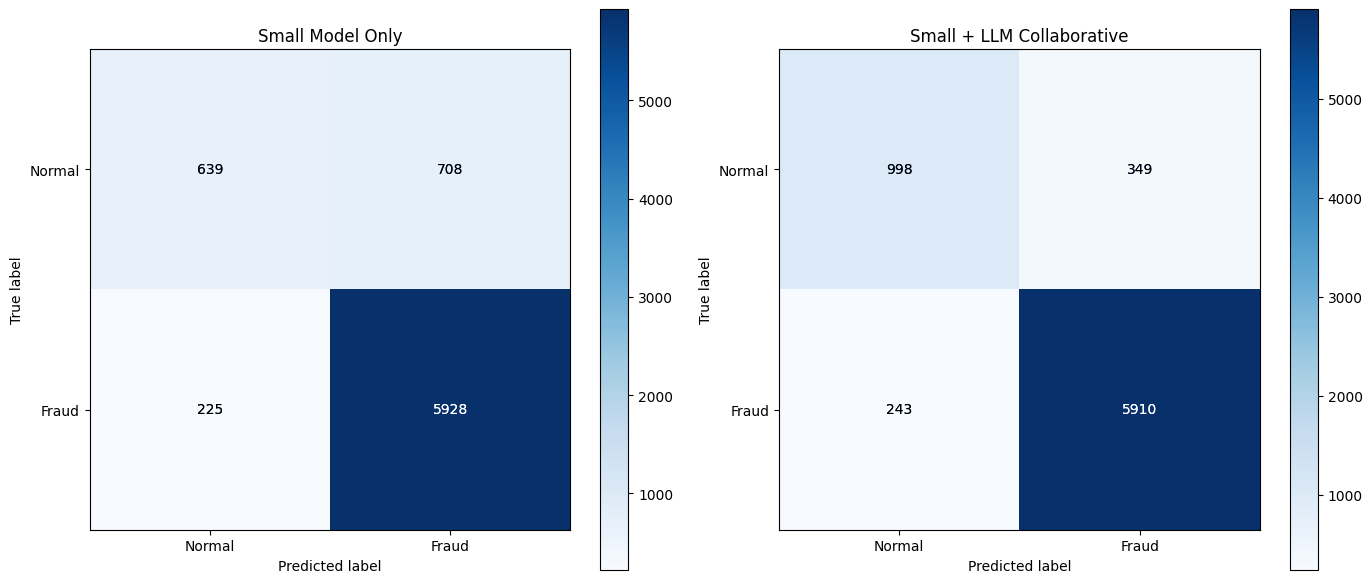

列联表 (0=错误, 1=正确):
col_0    0     1
row_0           
0      574   359
1       18  6549

McNemar's test statistic: 306.6313
p-value: 0.000000
结论: 小模型独立与协作框架之间的错误率差异具有统计学显著性 (p < 0.05)。


In [25]:
# ==================== 单元格13：混淆矩阵 & 统计显著性检验 ====================
import matplotlib.pyplot as plt
import warnings

# 抑制 findfont 警告
warnings.filterwarnings('ignore', message='.*findfont.*')

# 设置后备字体，避免找不到 SimHei 时报错
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# -------------------- 加载全量结果 --------------------
df = pd.read_csv('/kaggle/working/hard_collaboration_full.csv')

# 构建 2×2 混淆矩阵的函数
def plot_confusion(true, pred, title, ax):
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(title)
    # 添加精确的数值标签
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

# -------------------- 绘制并排混淆矩阵 --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_confusion(df['true_label'], df['small_pred'], 
               'Small Model Only', axes[0])
plot_confusion(df['true_label'], df['final_pred'], 
               'Small + LLM Collaborative', axes[1])

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------- McNemar 检验 --------------------
# 统计小模型和协作结果相对于真实标签的预测差异
# 构建列联表：两模型预测是否与真实标签一致（正确=1，错误=0）
small_correct = (df['small_pred'] == df['true_label']).astype(int)
collab_correct = (df['final_pred'] == df['true_label']).astype(int)

contingency = pd.crosstab(small_correct, collab_correct, margins=False)
print("列联表 (0=错误, 1=正确):")
print(contingency)

# McNemar 检验检测两个模型错误率是否有显著差异
# 格式：[[both_correct, small_correct_only], [collab_correct_only, both_wrong]]
b = contingency.loc[1, 0] if (1 in contingency.index and 0 in contingency.columns) else 0
c = contingency.loc[0, 1] if (0 in contingency.index and 1 in contingency.columns) else 0

if b + c > 0:
    table = np.array([[0, b], [c, 0]])  # 对角线填充 0（不影响 McNemar 统计量）
    result = mcnemar(table, exact=False, correction=True)
    print(f"\nMcNemar's test statistic: {result.statistic:.4f}")
    print(f"p-value: {result.pvalue:.6f}")
    if result.pvalue < 0.05:
        print("结论: 小模型独立与协作框架之间的错误率差异具有统计学显著性 (p < 0.05)。")
    else:
        print("结论: 差异无统计学显著性。")
else:
    print("\n错误样本数不足，无法进行 McNemar 检验。")

# 也可以直接使用 mcnemar 的内置参数：
# result = mcnemar(table, exact=False)  # 上面的代码已经完成